## Preamble

In [9]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt

c=299 #m/μs

In [2]:
from scipy.interpolate import RegularGridInterpolator

def resample2d(data, ni1, ni2, di1, di2, no1, no2, do1, do2):
    # 1. Reconstruct original physical coordinate axes
    xi1 = np.arange(ni1) * di1
    xi2 = np.arange(ni2) * di2
    
    # 2. Create the interpolator function from the original grid
    # bounds_error=False and fill_value=None allows extrapolation if grids do not align perfectly
    interp_func = RegularGridInterpolator((xi1, xi2), data, method='linear', 
                                         bounds_error=False, fill_value=None)
    
    # 3. Generate target physical coordinate axes
    xo1 = np.arange(no1) * do1
    xo2 = np.arange(no2) * do2
    
    # 4. Create a 2D mesh grid of target points for evaluation
    # 'ij' indexing matches the shape layout of the matrix (rows, columns)
    XO1, XO2 = np.meshgrid(xo1, xo2, indexing='ij')
    
    # 5. Reshape to a list of (x1, x2) coordinate pairs for the interpolator
    target_points = np.stack([XO1.ravel(), XO2.ravel()], axis=-1)
    
    # 6. Evaluate and reshape back to the target 2D shape
    resampled_array = interp_func(target_points).reshape(no1, no2)
    
    return resampled_array

In [3]:
def read(filename,n):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

def read_snap(filename,n,i=7):
    tmp=np.fromfile(filename,dtype='float32').reshape(n).T
    return tmp[24:24+nz,24:24+nx,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/FWI',setup='setup',np=1,nthreads=8,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

## Homo model

In [11]:
ε_r=12; μ_r=1

v = c/np.sqrt(ε_r*μ_r)
print('v =',v) #86 m/μs

fpeak = 400 #MHz

λmin = v/fpeak/2
print('λmin =',λmin) #0.1079 m

h=0.02 #m

nz=241; nx=241; print(f'length = {(nz-1)*h} m')
nzsnap=289; nxsnap=289; nsnap=51

dt_CFL = 0.6*h/v
print('dt_CFL =',dt_CFL) #μs
dt = 0.000139 #μs. SU_DT = 139 ps

nt = 1000 #T=0.139 μs
t=np.arange(0,nt*dt,dt)

v = 86.31386524384905
λmin = 0.10789233155481132
length = 4.8 m
dt_CFL = 0.000139027489570746


In [26]:
eps_r = ε_r*np.ones((nz,nx))
eps_r.T.astype('float32').tofile('model')

In [37]:
%%writefile setup

MODEL_SIZE              '241   241   1'
MODEL_SPACING           '0.02  0.02  1'
MODEL_ORIGIN            '0     0     0'
FILE_MODEL              'model'
MODEL_ATTRIBUTES        'eps_r'

ACQUI_GEOMETRY          spread
FS                      '1.6  1.6  0'
FR                      '1.6  1.6  0'
DR                      '  0    0  0'
NR                       1

IF_HICKS                 F

SCOMP                    Ey
RCOMP                    Ey

NT                       1000
DT                       0.000139
WAVELET_TYPE             ricker
FPEAK                    400

SNAPSHOT                'Hx Hz Ey'

IF_USE_CHECKPOINT        F

Overwriting setup


### run

In [32]:
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 2181064 Jun 19 12:59 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: f9d3f55
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/19/2026
System time: 12:59:58
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal

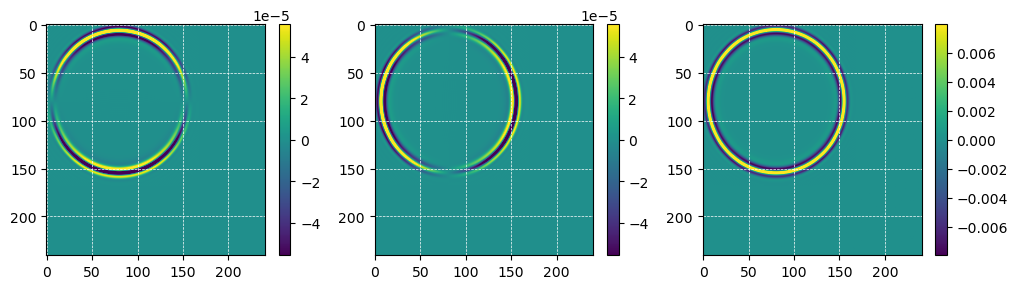

In [35]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('results/snap_fld_u%Hx'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('results/snap_fld_u%Hz'),perc=98)
plt.subplot(1,3,3); imshow(read_snap('results/snap_fld_u%Ey'),perc=98)

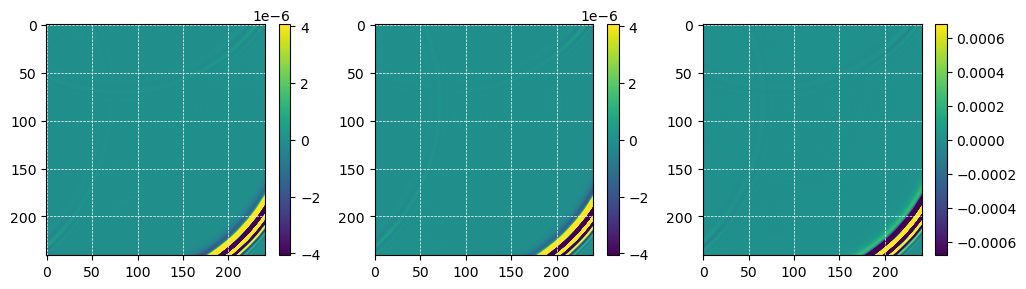

In [36]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('results/snap_fld_u%Hx',i=17),perc=98)
plt.subplot(1,3,2); imshow(read_snap('results/snap_fld_u%Hz',i=17),perc=98)
plt.subplot(1,3,3); imshow(read_snap('results/snap_fld_u%Ey',i=17),perc=98)

## Herten model line0
Roncoroni et al., 2025

nz,nx = 278, 640  
dz,dx = 27, 25 (mm)

In [53]:
!segyread tape=/home/wzhou/DATA/GPR_Roncoroni/data/SEGY/models/eps/line0_eps_25mm.sgy    | suflip flip=3 | sustrip > eps_r
!segyread tape=/home/wzhou/DATA/GPR_Roncoroni/data/SEGY/models/mu/line0_mu_25mm.sgy      | suflip flip=3 | sustrip > mu_r
!segyread tape=/home/wzhou/DATA/GPR_Roncoroni/data/SEGY/models/sigma/line0_sigm_25mm.sgy | suflip flip=3 | sustrip > sgma_r
#!segyread tape=/home/wzhou/DATA/GPR_Roncoroni/data/SEGY/models/sigma/line3_sigm_25mm.sgy | suflip flip=3 | sustrip > sgma_r

3200+0 records in
6+1 records out
3200 bytes (3.2 kB, 3.1 KiB) copied, 0.00316574 s, 1.0 MB/s
n1=278 n2=640 d1=0.001179
nt=278 ntr=640 dt=0.001179
ns=278
3200+0 records in
6+1 records out
3200 bytes (3.2 kB, 3.1 KiB) copied, 0.00342729 s, 934 kB/s
n1=278 n2=640 d1=0.001179
nt=278 ntr=640 dt=0.001179
ns=278
3200+0 records in
6+1 records out
3200 bytes (3.2 kB, 3.1 KiB) copied, 0.00320826 s, 997 kB/s
n1=278 n2=640 d1=0.001179
nt=278 ntr=640 dt=0.001179
ns=278


In [4]:
!segyread tape=./line0_eps_25mm.sgy    | suflip flip=3 | sustrip > eps_r
!segyread tape=./line0_mu_25mm.sgy      | suflip flip=3 | sustrip > mu_r
!segyread tape=./line0_sigm_25mm.sgy | suflip flip=3 | sustrip > sgma_r
#!segyread tape=/home/wzhou/DATA/GPR_Roncoroni/data/SEGY/models/sigma/line3_sigm_25mm.sgy | suflip flip=3 | sustrip > sgma_r

3200+0 records in
6+1 records out
3200 bytes (3.2 kB, 3.1 KiB) copied, 0.00540607 s, 592 kB/s
n1=278 n2=640 d1=0.001179
nt=278 ntr=640 dt=0.001179
ns=278
3200+0 records in
6+1 records out
3200 bytes (3.2 kB, 3.1 KiB) copied, 0.00261168 s, 1.2 MB/s
n1=278 n2=640 d1=0.001179
nt=278 ntr=640 dt=0.001179
ns=278
3200+0 records in
6+1 records out
3200 bytes (3.2 kB, 3.1 KiB) copied, 0.00267402 s, 1.2 MB/s
n1=278 n2=640 d1=0.001179
nt=278 ntr=640 dt=0.001179
ns=278


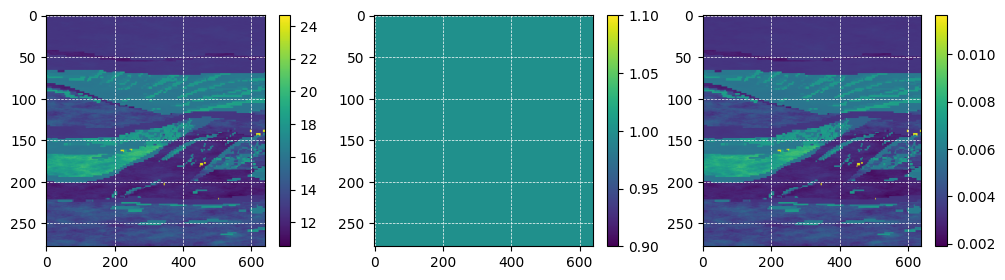

In [23]:
ε_r=read('eps_r' ,(640,278))
μ_r=read('mu_r'  ,(640,278))
σ_r=read('sgma_r',(640,278))

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(ε_r)
plt.subplot(1,3,2); imshow(μ_r)
plt.subplot(1,3,3); imshow(σ_r)

In [10]:
v = c/np.sqrt(ε_r*μ_r)
print('vmin,vmax =',v.min(),v.max())

vmin,vmax = 60.230625 92.11606


### 50 MHz

In [53]:
fpeak = 50 #MHz

λmin = v.min()/fpeak/2
print('λmin, λmin/5 =',λmin,λmin/5)

h=0.12 #m

nz=int(278*0.027/h)
nx=int(640*0.025/h)
print(f'nz,nx = {nz,nx}')
nzsnap=nz+48
nxsnap=nx+48
nsnap=50
print(f'nzsnap,nxsnap = {nzsnap,nxsnap}')

dt_CFL = 0.6*h/299.80 #v.max()
print('dt_CFL =',dt_CFL) #μs
dt = 0.000240 #μs. SU_DT = 240 ps

T=0.3 #μs
print('T=0.3 μs gives nt = ',int(T/dt))
nt=1250
# t=np.arange(0,nt*dt,dt)

nr=160

λmin, λmin/5 = 0.60230625 0.12046125
nz,nx = (62, 133)
nzsnap,nxsnap = (110, 181)
dt_CFL = 0.00024016010673782518
T=0.3 μs gives nt =  1250


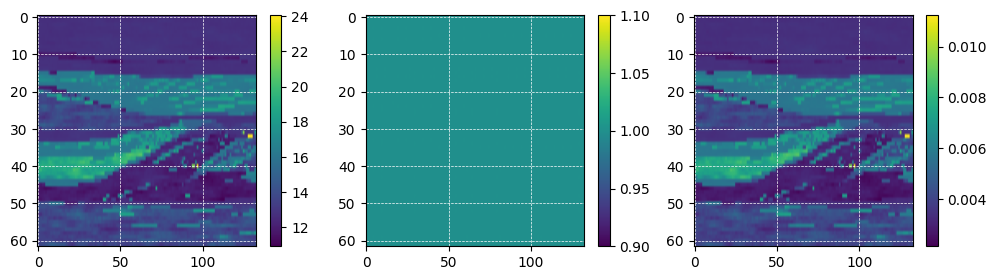

In [54]:
# resample
ε_r = resample2d(read('eps_r' ,(640,278)), 278,640, 0.027,0.025, nz,nx, h,h)
μ_r = resample2d(read('mu_r'  ,(640,278)), 278,640, 0.027,0.025, nz,nx, h,h)
σ_r = resample2d(read('sgma_r',(640,278)), 278,640, 0.027,0.025, nz,nx, h,h)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(ε_r)
plt.subplot(1,3,2); imshow(μ_r)
plt.subplot(1,3,3); imshow(σ_r)

In [55]:
ε_r.T.astype('float32').tofile( f'eps_r.{h}')
μ_r.T.astype('float32').tofile(  f'mu_r.{h}')
σ_r.T.astype('float32').tofile(f'sgma_r.{h}')

!cat eps_r.$h mu_r.$h sgma_r.$h > model

In [63]:
%%writefile setup
DIR_OUT                 'res_50MHz'

MODEL_SIZE              '62    133   1'
MODEL_SPACING           '0.12  0.12  1'
MODEL_ORIGIN            '0     0     0'
FILE_MODEL              'model'
MODEL_ATTRIBUTES        'eps_r mu_r sgma'

ACQUI_GEOMETRY          spread
FS                      '  0    6  0'
FR                      '  0    0  0'
DR                      '  0  0.1  0'
NR                       160

IF_HICKS                 T

SCOMP                    Ey
RCOMP                    Ey

FPEAK                    50

NT                       1250
DT                       0.000240
WAVELET_TYPE             ricker

SNAPSHOT                'Hx Hz Ey'

IF_USE_CHECKPOINT        F

Overwriting setup


In [64]:
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 2175872 Jun 19 17:46 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: cfd890f
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/19/2026
System time: 21:38:31
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_50MHz
 Output directory:res_50MHz/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 0

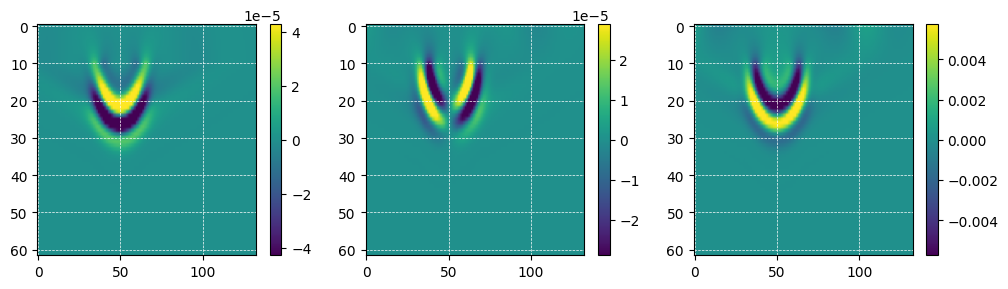

In [28]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_50MHz/snap_fld_u%Hx',(51,181,120)),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_50MHz/snap_fld_u%Hz',(51,181,120)),perc=98)
plt.subplot(1,3,3); imshow(read_snap('res_50MHz/snap_fld_u%Ey',(51,181,120)),perc=98)

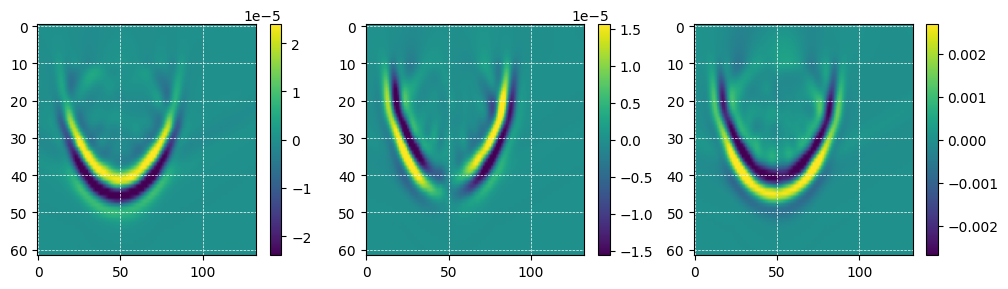

In [29]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_50MHz/snap_fld_u%Hx',(51,181,120),i=12),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_50MHz/snap_fld_u%Hz',(51,181,120),i=12),perc=98)
plt.subplot(1,3,3); imshow(read_snap('res_50MHz/snap_fld_u%Ey',(51,181,120),i=12),perc=98)

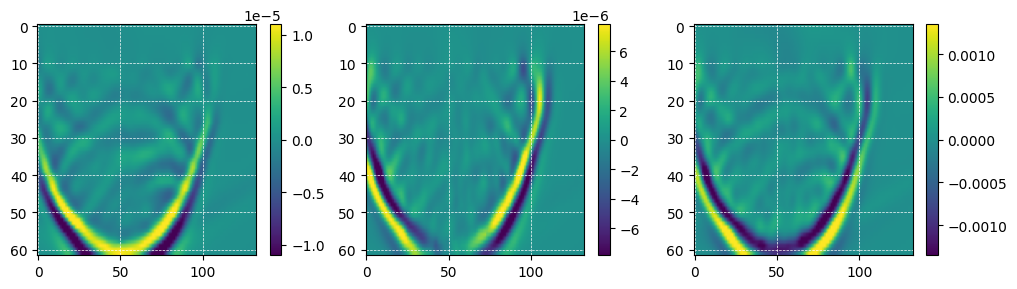

In [30]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_50MHz/snap_fld_u%Hx',(51,181,120),i=17),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_50MHz/snap_fld_u%Hz',(51,181,120),i=17),perc=98)
plt.subplot(1,3,3); imshow(read_snap('res_50MHz/snap_fld_u%Ey',(51,181,120),i=17),perc=98)

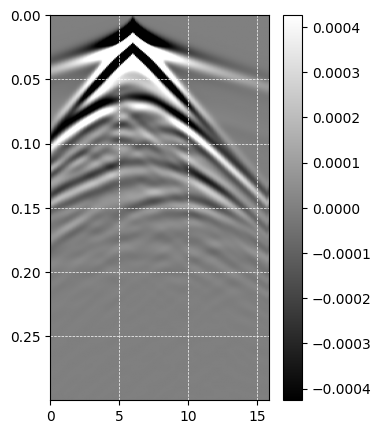

In [65]:
plt.figure(figsize=(12,5))
plt.subplot(1,3,2); imshow(read_su('res_50MHz/Ru_Shot0001.su',(nr,nt)),cmap='gray',extent=[0,0.1*(nr-1),dt*(nt-1),0],perc=95)

### 100 MHz

In [32]:
fpeak = 100 #MHz

λmin = v.min()/fpeak/2
print('λmin, λmin/5 =',λmin,λmin/5)

h=0.06 #m

nz=int(278*0.027/h)
nx=int(640*0.025/h)
print(f'nz,nx = {nz,nx}')
nzsnap=nz+48
nxsnap=nx+48
nsnap=50
print(f'nzsnap,nxsnap = {nzsnap,nxsnap}')

dt_CFL = 0.6*h/299.80 #v.max()
print('dt_CFL =',dt_CFL) #μs
dt = 0.000120 #μs. SU_DT = 120 ps

T=0.3 #μs
print('T=0.3 μs gives nt = ',int(T/dt))
nt=2500
# t=np.arange(0,nt*dt,dt)

nr=160

λmin, λmin/5 = 0.30115312 0.060230624
nz,nx = (125, 266)
nzsnap,nxsnap = (173, 314)
dt_CFL = 0.00012008005336891259
T=0.3 μs gives nt =  2500


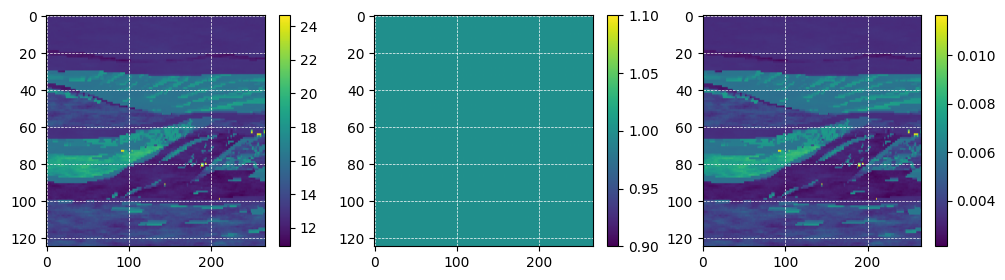

In [33]:
# resample
ε_r = resample2d(read('eps_r' ,(640,278)), 278,640, 0.027,0.025, nz,nx, h,h)
μ_r = resample2d(read('mu_r'  ,(640,278)), 278,640, 0.027,0.025, nz,nx, h,h)
σ_r = resample2d(read('sgma_r',(640,278)), 278,640, 0.027,0.025, nz,nx, h,h)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(ε_r)
plt.subplot(1,3,2); imshow(μ_r)
plt.subplot(1,3,3); imshow(σ_r)

In [16]:
ε_r.T.astype('float32').tofile( f'eps_r.{h}')
μ_r.T.astype('float32').tofile(  f'mu_r.{h}')
σ_r.T.astype('float32').tofile(f'sgma_r.{h}')

!cat eps_r.$h mu_r.$h sgma_r.$h > model

In [19]:
%%writefile setup
DIR_OUT                 'res_100MHz'

MODEL_SIZE              '125    266   1'
MODEL_SPACING           '0.06  0.06  1'
MODEL_ORIGIN            '0     0     0'
FILE_MODEL              'model'
MODEL_ATTRIBUTES        'eps_r mu_r sgma'

ACQUI_GEOMETRY          spread
FS                      '  0    6  0'
FR                      '  0    0  0'
DR                      '  0  0.1  0'
NR                       160

IF_HICKS                 T

SCOMP                    Ey
RCOMP                    Ey

FPEAK                    100

NT                       2500
DT                       0.000120
WAVELET_TYPE             ricker

SNAPSHOT                'Hx Hz Ey'

IF_USE_CHECKPOINT        F

Overwriting setup


In [18]:
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 2175872 Jun 19 17:46 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: cfd890f
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/19/2026
System time: 21:13:49
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
  

### 200 MHz

In [43]:
fpeak = 200 #MHz

λmin = v.min()/fpeak/2
print('λmin, λmin/5 =',λmin,λmin/5)

h=0.03 #m

nz=int(278*0.027/h)
nx=int(640*0.025/h)
print(f'nz,nx = {nz,nx}')
nzsnap=nz+48
nxsnap=nx+48
nsnap=50
print(f'nzsnap,nxsnap = {nzsnap,nxsnap}')

dt_CFL = 0.6*h/299.80 #v.max()
print('dt_CFL =',dt_CFL) #μs
dt = 0.000060 #μs. SU_DT = 60 ps

T=0.3 #μs
print('T=0.3 μs gives nt = ',int(T/dt))
nt=5000
# t=np.arange(0,nt*dt,dt)

nr=160

λmin, λmin/5 = 0.15057656 0.030115312
nz,nx = (250, 533)
nzsnap,nxsnap = (298, 581)
dt_CFL = 6.0040026684456295e-05
T=0.3 μs gives nt =  5000


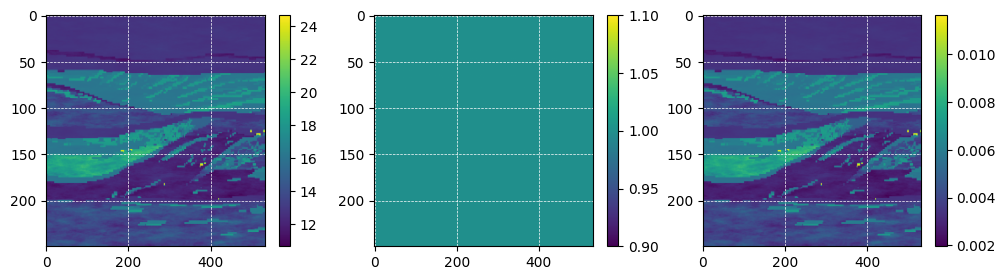

In [44]:
# resample
ε_r = resample2d(read('eps_r' ,(640,278)), 278,640, 0.027,0.025, nz,nx, h,h)
μ_r = resample2d(read('mu_r'  ,(640,278)), 278,640, 0.027,0.025, nz,nx, h,h)
σ_r = resample2d(read('sgma_r',(640,278)), 278,640, 0.027,0.025, nz,nx, h,h)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(ε_r)
plt.subplot(1,3,2); imshow(μ_r)
plt.subplot(1,3,3); imshow(σ_r)

In [45]:
ε_r.T.astype('float32').tofile( f'eps_r.{h}')
μ_r.T.astype('float32').tofile(  f'mu_r.{h}')
σ_r.T.astype('float32').tofile(f'sgma_r.{h}')

!cat eps_r.$h mu_r.$h sgma_r.$h > model

In [49]:
%%writefile setup
DIR_OUT                 'res_200MHz'

MODEL_SIZE              '250    533   1'
MODEL_SPACING           '0.03  0.03  1'
MODEL_ORIGIN            '0     0     0'
FILE_MODEL              'model'
MODEL_ATTRIBUTES        'eps_r mu_r sgma'

ACQUI_GEOMETRY          spread
FS                      '  0    6  0'
FR                      '  0    0  0'
DR                      '  0  0.1  0'
NR                       160

IF_HICKS                 T

SCOMP                    Ey
RCOMP                    Ey

FPEAK                    200

NT                       5000
DT                       0.000060 #0.06 ns
WAVELET_TYPE             ricker

SNAPSHOT                'Hx Hz Ey'

IF_USE_CHECKPOINT        F

Overwriting setup


In [50]:
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 2175872 Jun 19 17:46 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: cfd890f
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/19/2026
System time: 21:34:04
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_200MHz
 Output directory:res_200MHz/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or

### plots

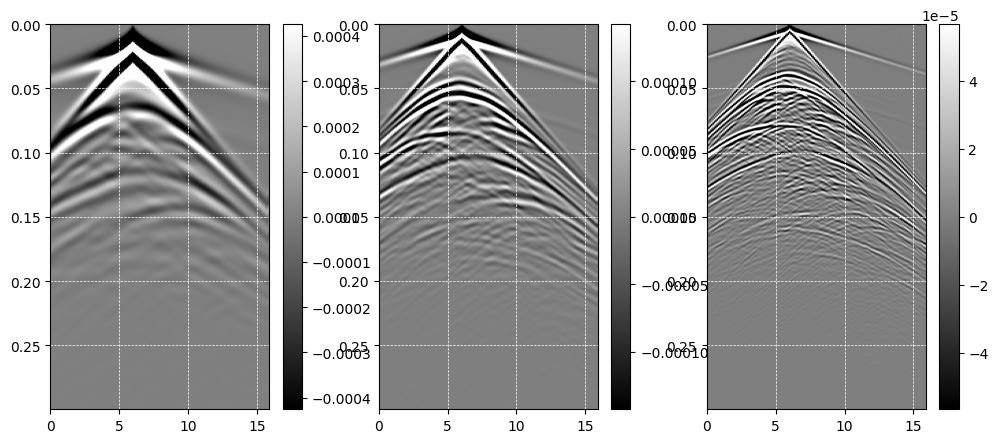

In [51]:
plt.figure(figsize=(12,5))
plt.subplot(1,3,1); imshow(read_su('res_50MHz/Ru_Shot0001.su', (nr,1250)),cmap='gray',extent=[0,0.1*(nr-1),0.000240*(1250-1),0],perc=95)
plt.subplot(1,3,2); imshow(read_su('res_100MHz/Ru_Shot0001.su',(nr,2500)),cmap='gray',extent=[0,0.1*(nr-1),0.000120*(2500-1),0],perc=95)
plt.subplot(1,3,3); imshow(read_su('res_200MHz/Ru_Shot0001.su',(nr,5000)),cmap='gray',extent=[0,0.1*(nr-1),0.000060*(5000-1),0],perc=95)

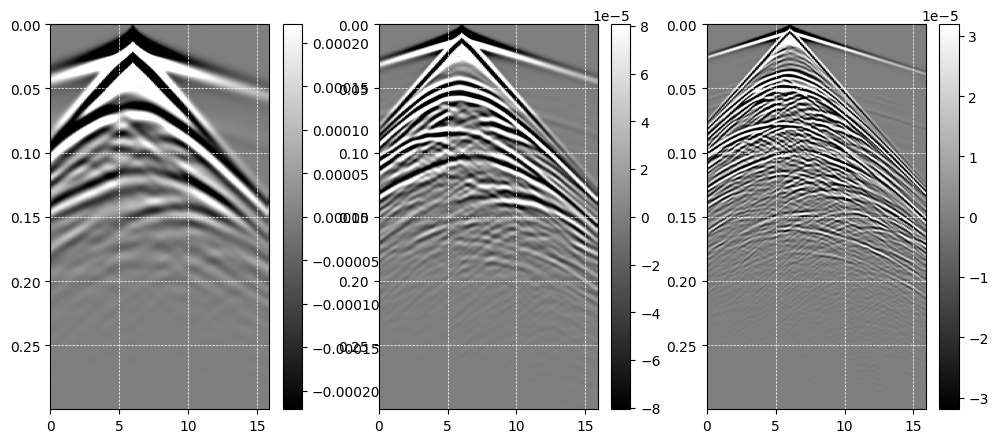

In [52]:
plt.figure(figsize=(12,5))
plt.subplot(1,3,1); imshow(read_su('res_50MHz/Ru_Shot0001.su', (nr,1250)),cmap='gray',extent=[0,0.1*(nr-1),0.000240*(1250-1),0],perc=90)
plt.subplot(1,3,2); imshow(read_su('res_100MHz/Ru_Shot0001.su',(nr,2500)),cmap='gray',extent=[0,0.1*(nr-1),0.000120*(2500-1),0],perc=90)
plt.subplot(1,3,3); imshow(read_su('res_200MHz/Ru_Shot0001.su',(nr,5000)),cmap='gray',extent=[0,0.1*(nr-1),0.000060*(5000-1),0],perc=90)